# Эксперимтенты

In [1]:
from pathlib import Path
import rasterio as rs

raster_path = Path(r"D:\ml_datasets\Chukotka\DEM\dem_120m.tif")
ds = rs.open(raster_path)

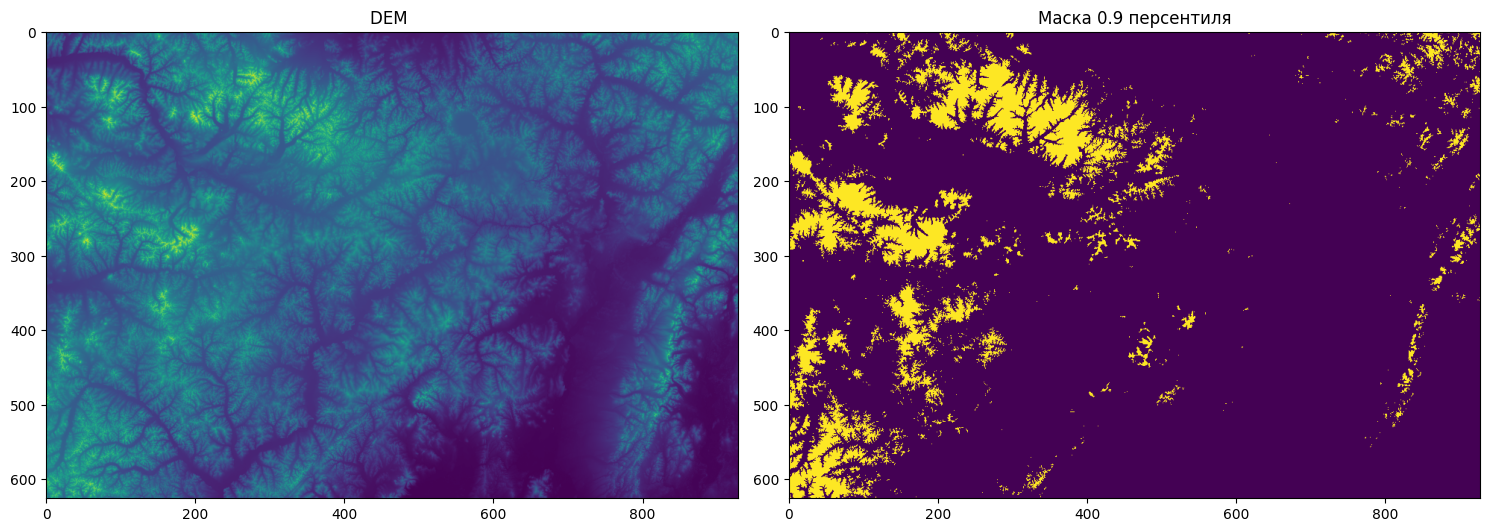

In [19]:
import torch
import matplotlib.pyplot as plt

p = 0.9
fig, ax = plt.subplots(1, 2, figsize = (15, 6))
tensor = torch.tensor(ds.read(1))
p95 = torch.quantile(tensor.flatten()[::100], p)  # используйте перцентиль
binmask = tensor > p95

ax[0].imshow(tensor[::10, ::10])
ax[0].set_title('DEM ')
ax[1].imshow(binmask[::10, ::10])
ax[1].set_title(f'Маска {p} персентиля')

plt.tight_layout()
plt.show()

# Box-counting method

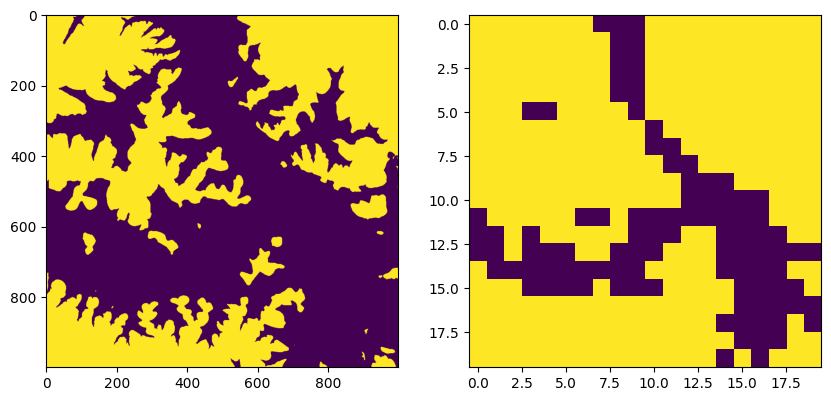

In [3]:
fig, ax = plt.subplots(1, 2, figsize= (10, 10))

cropped = binmask[1000:2000, 1000:2000]
ax[0].imshow(cropped)


# MaxPool2d - добавляем batch и channel размерности
cropped_tensor = cropped.float().unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
pooled = torch.nn.functional.max_pool2d(cropped_tensor, kernel_size=50)
pooled = pooled.squeeze()  # обратно в 2D [H/10, W/10]

ax[1].imshow(pooled)

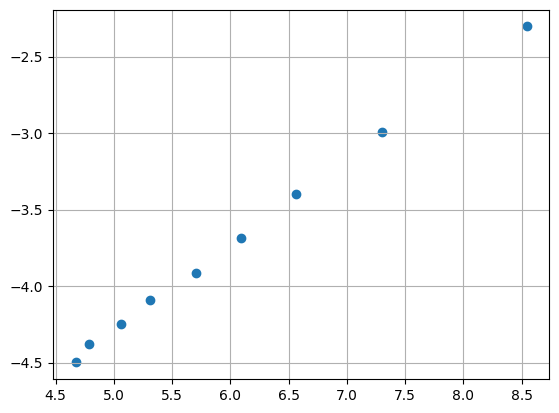

In [41]:
from utils.box_counting import count_boxes


box_count = []
box_size = []
for i in range(1, 10):
    size = i*10
    box_size.append(size)
    box_count.append(count_boxes(
        cropped,
        box_size=size
    ))

from sklearn.linear_model import LinearRegression
import numpy as np


reg = LinearRegression().fit(np.log(box_count).reshape(-1, 1), -np.log(box_size))

plt.scatter(np.log(box_count), -np.log(box_size))
plt.grid()

# Анализ линеаментов

In [80]:
from pathlib import Path

from utils.box_counting import get_fractal_dimention
import rasterio as rs

lineaments_dir = Path(r"D:\ml_datasets\Chukotka\DEM\Линеаменты растр (полные)")
lineaments = {}
for f in lineaments_dir.iterdir():
    title = f.stem.split()[-1]
    scale = int(title.replace('m', ""))
    lineaments[scale] = f

fractal_scales = {}
for scale in lineaments:
    fractal_scales[scale] = (
        get_fractal_dimention(torch.tensor(rs.open(lineaments[scale]).read(1)) > 200))


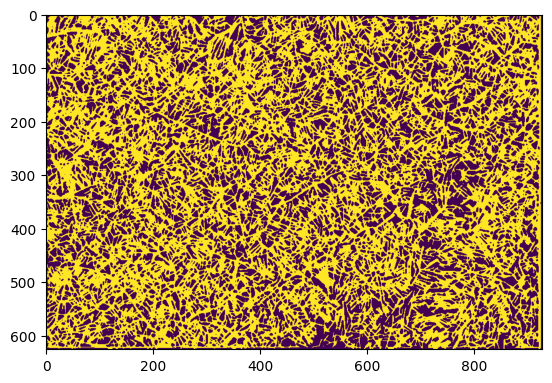

In [78]:
plt.imshow(rs.open(lineaments[1200]).read(1) > 200)

In [99]:
x_sorted

(120, 240, 480, 600, 900, 1200)

In [91]:
fractal_scales
x = list(fractal_scales.keys())
y = list(fractal_scales.values())

# Сортируем по x (чтобы линия не прыгала)
sorted_pairs = sorted(zip(x, y))
x_sorted, y_sorted = zip(*sorted_pairs)

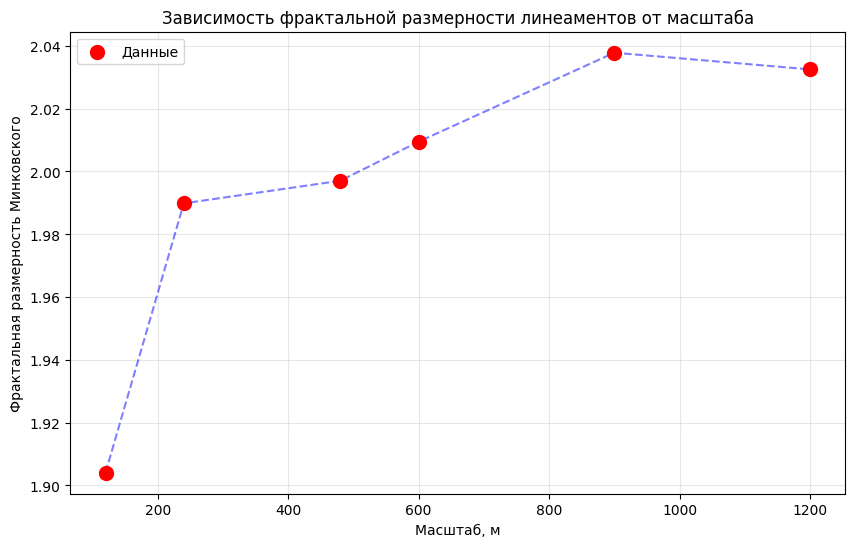

: 

In [ ]:
# plt.plot(x_sorted ,y_sorted)

# Строим график
plt.figure(figsize=(10, 6))
plt.scatter(x_sorted, y_sorted, s=100, color='red', label='Данные', zorder=5)
plt.plot(x_sorted, y_sorted, 'b--', alpha=0.5)

plt.grid()
plt.xlabel('Масштаб, м')
plt.ylabel('Фрактальная размерность Минковского')
plt.title('Зависимость фрактальной размерности линеаментов от масштаба')
plt.grid(True, alpha=0.3)
plt.legend()